<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
fashion_mnist = keras.datasets.fashion_mnist

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Штани", "Пуловер", "Сукня", "Пальто",
               "Сандалі", "Сорочка", "Кросівки", "Сумка", "Черевики"]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (55000, 28, 28)
X_test: (10000, 28, 28)


In [5]:
X_train_cnn = X_train[..., tf.newaxis]
X_valid_cnn = X_valid[..., tf.newaxis]
X_test_cnn = X_test[..., tf.newaxis]

In [6]:
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_valid_cnn, y_valid),
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8360 - loss: 0.4719 - val_accuracy: 0.9012 - val_loss: 0.2703 - learning_rate: 0.0010
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8931 - loss: 0.3045 - val_accuracy: 0.9152 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9029 - loss: 0.2714 - val_accuracy: 0.9084 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 4/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9139 - loss: 0.2419 - val_accuracy: 0.8974 - val_loss: 0.2834 - learning_rate: 0.0010
Epoch 5/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9262 - loss: 0.2071 - val_accuracy: 0.9324 - val_loss: 0.1874 - learning_rate: 5.0000e-04
Epoch 6/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9300 - loss: 0.1963 - val_accuracy: 0.9318 - val_loss: 0.1904 - learning_rate: 5.0000e-04
Epoch 7/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9325 - loss:

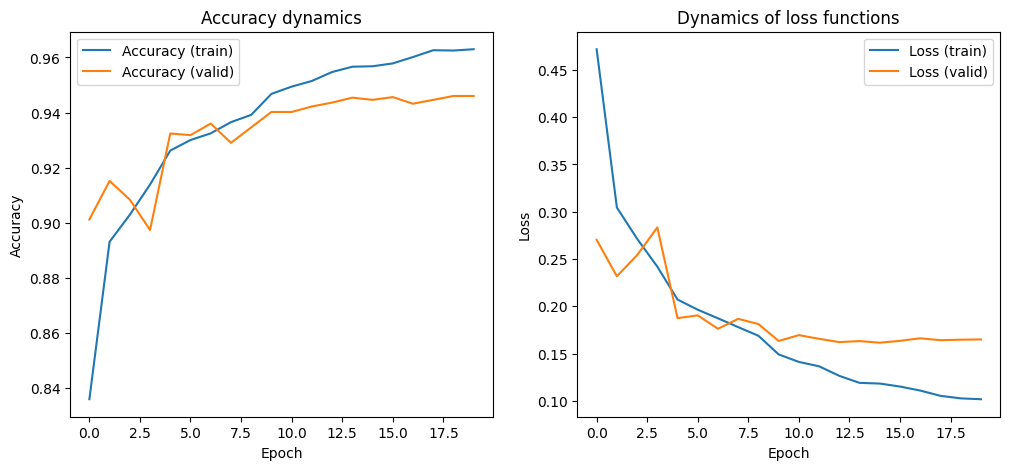

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [8]:
test_loss, test_accuracy = model_cnn.evaluate(X_test_cnn, y_test)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9377 - loss: 0.1829
Test accuracy: 94%
Test loss: 0.1829


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

model_cnn_1 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_cnn_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model_cnn_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,57

 Total params: 1,314,368 (5.01 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 875,478 (3.34 MB)

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model_cnn_1.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_valid_cnn, y_valid),
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.6595 - loss: 0.9607 - val_accuracy: 0.7418 - val_loss: 0.7380 - learning_rate: 0.0010
Epoch 2/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7637 - loss: 0.6436 - val_accuracy: 0.7802 - val_loss: 0.5796 - learning_rate: 0.0010
Epoch 3/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.7942 - loss: 0.5679 - val_accuracy: 0.8446 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 4/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8154 - loss: 0.5102 - val_accuracy: 0.8492 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 5/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8247 - loss: 0.4764 - val_accuracy: 0.8576 - val_loss: 0.3737 - learning_rate: 0.0010
Epoch 6/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8342 - loss: 0.4549 - val_accuracy: 0.8776 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 7/30
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8403 - l

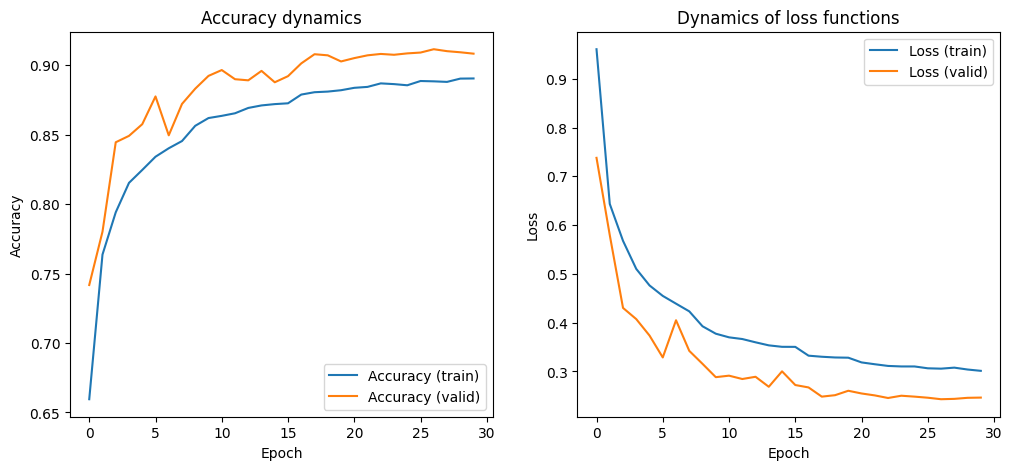

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [13]:
test_loss, test_accuracy = model_cnn_1.evaluate(X_test_cnn, y_test)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8977 - loss: 0.2743
Test accuracy: 90%
Test loss: 0.2743


In [17]:
X_train_vgg = np.repeat(X_train[..., np.newaxis], 3, axis=-1)
X_valid_vgg = np.repeat(X_valid[..., np.newaxis], 3, axis=-1)
X_test_vgg = np.repeat(X_test[..., np.newaxis], 3, axis=-1)

In [20]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

base_model.trainable = False

model_vgg_0 = models.Sequential([
    layers.Input(shape=(28, 28, 3)),
    layers.Resizing(32, 32),
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_vgg_0.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg_0.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
model_vgg_0.fit(
    X_train_vgg, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_valid_vgg, y_valid)
)

Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.6075 - loss: 1.1683 - val_accuracy: 0.7844 - val_loss: 0.6672
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7580 - loss: 0.7014 - val_accuracy: 0.8106 - val_loss: 0.5612
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7878 - loss: 0.6102 - val_accuracy: 0.8268 - val_loss: 0.5066
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8020 - loss: 0.5627 - val_accuracy: 0.8348 - val_loss: 0.4736
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8137 - loss: 0.5282 - val_accuracy: 0.8428 - val_loss: 0.4503


In [22]:
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model_vgg_0.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_vgg_0.fit(
    X_train_vgg, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_valid_vgg, y_valid),
    callbacks=[early_stopping]
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8509 - loss: 0.4135 - val_accuracy: 0.8836 - val_loss: 0.3180
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.8795 - loss: 0.3309 - val_accuracy: 0.8928 - val_loss: 0.2956
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8930 - loss: 0.2960 - val_accuracy: 0.8976 - val_loss: 0.2806
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9032 - loss: 0.2667 - val_accuracy: 0.9036 - val_loss: 0.2675
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9105 - loss: 0.2461 - val_accuracy: 0.9032 - val_loss: 0.2598
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9172 - loss: 0.2297 - val_accuracy: 0.9086 - val_loss: 0.2556
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9220 - loss: 0.2152 - val_accuracy: 0.9066 - val_loss: 0.2590
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9272 - loss: 0.2017 - 

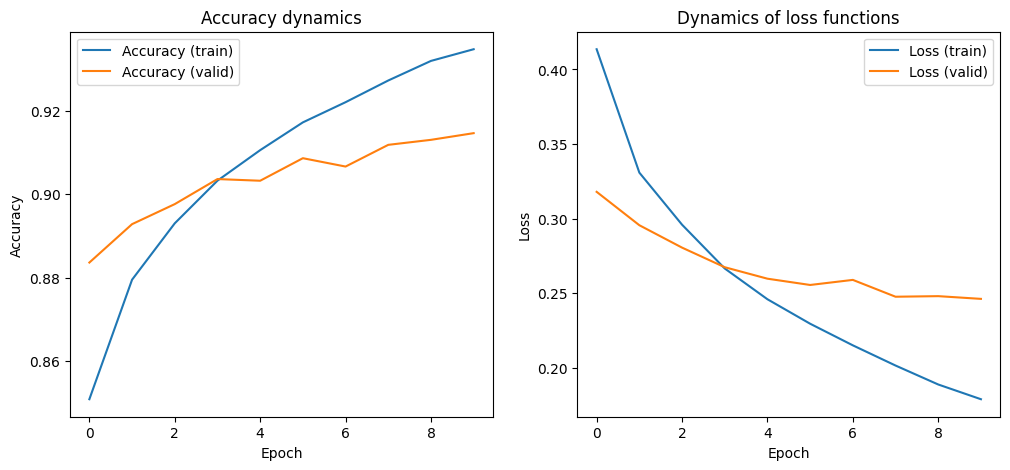

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [26]:
test_loss, test_accuracy = model_vgg_0.evaluate(X_test_vgg, y_test)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9083 - loss: 0.2668
Test accuracy: 91%
Test loss: 0.2668


Висновок:

Згорткові мережі показали значну перевагу. CNN досягла 94%, оскільки згорткові шари ефективно аналізують просторові зв'язки та локальні ознаки (контури, краї, лінії одягу), зберігаючи двовимірну структуру матриці пікселів. Звичайна повнозв'язна мережа, яка досягла 91%, згладжує зображення у довгий вектор і втрачає інформацію про те, які пікселі були поруч.

Порівняння CNN (94%) та VGG16 (91%): Спеціалізована невелика CNN виявилася ефективнішою за важку предобучену архітектуру VGG16. Трансферне навчання за допомогою VGG16 має обмежену ефективність на спрощених датасетах на кшталт Fashion MNIST, оскільки ваги ImageNet налаштовані на складні природні об'єкти, а не на низькороздільні силуети предметів гардероба. Для подібних завдань краще підходять компактні моделі, навчені з нуля.